In [1]:
from FormUtils import pyForm, capture_physics_expr

In [ ]:
%%pyForm ee_to_mumu

* Process: e+ e- -> mu+ mu- 

#-
* Above suppresses extra output
Off Statistics;
Off FinalStats;

#include amplitude.h

* Kinematic variables
Symbols s, t, u;

* Physical constants
Symbols e, pi, alpha, Mass;

* Three momenta ratio in CM
Symbols pfInOutRatio;


Local M = (e^2) * (VB(i1, p2, 0) * g(i1, i2, mu1) * U(i2, p1, 0)) 
                * phprop(mu1, mu2, q)  
                * (UB(i3, p3, Mass) * g(i3, i4, mu2) * V(i4, p4, Mass));
#call squareamplitude(M, Msq)
.sort

* Spin averaging (1/2 * 1/2)
multiply 1/4; 
* coupling
id e^4 = 16 * pi^2 * alpha^2;
* propagator handling
id q = p1 + p2;
id prop(x?) = (x)^-1;
id (q.q)^-1 = (s)^-1;
.sort


* Kinematics 
repeat;

    id p1.p1 = 0;
    id p2.p2 = 0;
    id p3.p3 = Mass^2;
    id p4.p4 = Mass^2;
    
    id p1.p2 = (s - p1.p1 - p2.p2)/2;
    id p3.p4 = (s - p3.p3 - p4.p4)/2;
    
    
    id p1.p3 = (p1.p1 + p3.p3 - t)/2;
    id p2.p4 = (p2.p2 + p4.p4 - t)/2;

   
    id p1.p4 = (p1.p1 + p4.p4 - u)/2;
    id p2.p3 = (p2.p2 + p3.p3 - u)/2;
endrepeat;
.sort


bracket alpha, s;
.sort
* Save
Format C;
#write <ee_to_mumu.txt> "%e;", Msq;
.sort
* Print
Format;
Print Msq;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Sun Apr 12 15:42:56 2026
    
    * Process: e+ e- -> mu+ mu- 
    
    #-

   Msq =
      64*s^(-2)*pi^2*alpha^2*Mass^4 - 64*s^(-2)*u*pi^2*alpha^2*Mass^2 + 32*
      s^(-2)*u^2*pi^2*alpha^2 - 64*s^(-2)*t*pi^2*alpha^2*Mass^2 + 32*s^(-2)*
      t^2*pi^2*alpha^2 + 64*s^(-1)*pi^2*alpha^2*Mass^2;




<|M^2|> =  32*pi**2*alpha**2*(2*Mass**4 + 2*Mass**2*s - 2*Mass**2*t - 2*Mass**2*u + t**2 + u**2)/s**2
dsigma/dOmega CM =  alpha**2*sqrt(-4*Mass**2 + s)*(Mass**4 - 2*Mass**2*Mass**2 + Mass**2*s + Mass**2*s + Mass**4 - Mass**2*s*cos(theta)**2 - Mass**2*s + s**2*cos(theta)**2/4 + s**2/4)/(s**2*s**(3/2))
Sigma = 4*pi*alpha**2*sqrt(-4*Mass**2 + s)*(3*Mass**4 - 6*Mass**2*Mass**2 - 4*Mass**2*s + 3*Mass**4 + 3*Mass**2*s + 3*Mass**2*s + s**2)/(3*s**2*s**(3/2))


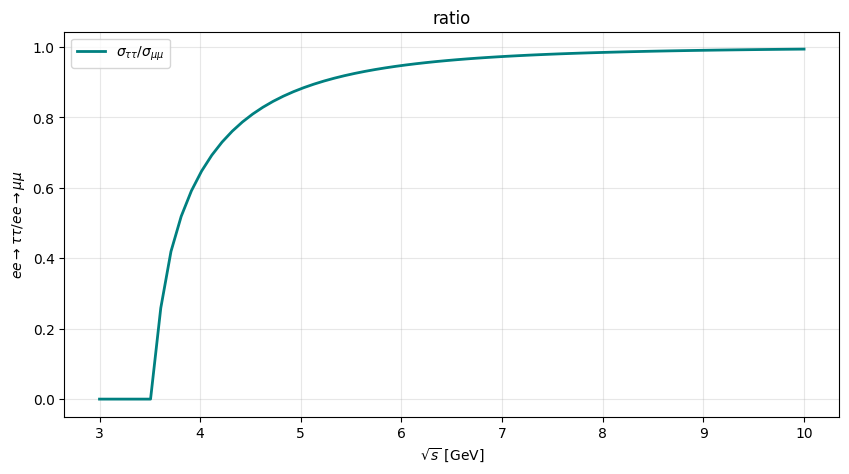

In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from Kinematics import XS_2To2_CM

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.grid"] = True


# Capture Raw FORM ouput
form_expr = capture_physics_expr("scripts/ee_to_mumu.txt")
# Convert FORM to sympy
s, alpha, Mass = sp.symbols("s alpha Mass", positive = True)
t,u = sp.symbols("t u")
Msq = sp.simplify(form_expr)
print(f"<|M^2|> =  {Msq}")

# Call the method to get the xs in CM
theta = sp.Symbol("theta", real=True)
xs = XS_2To2_CM(Msq, s, t, u, theta, 0, 0, Mass, Mass)
print(f"dsigma/dOmega CM =  {xs}")

# integrate
phi = sp.Symbol("phi", real=True)
total_xs = sp.integrate(xs * sp.sin(theta), (theta, 0, sp.pi), (phi, 0, 2 * sp.pi))

print(f"Sigma = {sp.simplify(total_xs)}")


# lambdify
total_xs_lambda = sp.lambdify((s, alpha, Mass), total_xs, "numpy")

angles = np.linspace(0, np.pi, 100)
cos_theta = np.cos(angles)
sqrtS_vals = np.linspace(3.0, 10.0, 70)
s_val = sqrtS_vals * sqrtS_vals
alphaVals = (1 / 137.036) / (
    1 - (1 / (137.036 * 3 * np.pi)) * np.log(sqrtS_vals**2 / 5.11e-4**2)
)

# We need to make sure we are above threshold
sigma_mu = np.zeros_like(s_val)
mMuon = 0.10566
mask_muons = s_val >= (2 * mMuon) ** 2
sigma_tau = np.zeros_like(s_val)
mTau = 1.7768
mask_taus = s_val >= (2 * mTau) ** 2

sigma_mu[mask_muons] = total_xs_lambda(s_val[mask_muons], alphaVals[mask_muons], mMuon)
sigma_tau[mask_taus] = total_xs_lambda(s_val[mask_taus], alphaVals[mask_taus], mTau)
ratio_vals = sigma_tau / sigma_mu

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(
    sqrtS_vals,
    ratio_vals,
    color="teal",
    lw=2,
    label=r"$\sigma_{\tau\tau}/\sigma_{\mu\mu}$",
)
plt.title("ratio")
plt.xlabel(r"$\sqrt{s}$ [GeV]")
plt.ylabel(r"$ {ee \to \tau \tau / ee \to \mu \mu}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()